In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pickle
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import PCA

import config
from utils.helpers import get_max, separate_dataset
from models import SingleTransformer
from train import train_mlm, train_cls
from evaluate import evaluate_mlm, evaluate_cls_cv
from data import load_data, create_dataset
from interpretation.metrics import compute_confusion_matrices, compute_metrics_from_confusion_matrix
from interpretation.visualization import *
from interpretation.similarity import compute_similarity_matrix
from interpretation.latentspace import get_latent_space

sns.set_style("whitegrid")
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)

In [2]:
# adata_RNA_labelled, adata_RNA_unlabelled, df_degs = load_data.load_processed_rna(verbose=True)
# with open('objects/rna_labelled.pkl', 'wb') as f:
#     pickle.dump(adata_RNA_labelled, f)
# with open('objects/rna_unlabelled.pkl', 'wb') as f:
#     pickle.dump(adata_RNA_unlabelled, f)
# with open('objects/degs.pkl', 'wb') as f:
#     pickle.dump(df_degs, f)

with open('objects/rna_labelled.pkl', 'rb') as f:
    adata_RNA_labelled = pickle.load(f)
with open('objects/rna_unlabelled.pkl', 'rb') as f:
        adata_RNA_unlabelled = pickle.load(f)
with open('objects/degs.pkl', 'rb') as f:
        df_degs = pickle.load(f)

print("RNA data loaded.",
        "\nRNA D3 Labelled:", adata_RNA_labelled.shape, adata_RNA_labelled.obs.shape,  list(adata_RNA_labelled.var_names)[:5],"...",
        "\nRNA D3 Un-Labelled:", adata_RNA_unlabelled.shape, adata_RNA_unlabelled.obs.shape, list(adata_RNA_unlabelled.var_names)[:5],"...")

RNA data loaded. 
RNA D3 Labelled: (2008, 944) (2008, 16) ['Upk1b', '2010300F17Rik', 'Tspan13', 'Tnmd', 'F2rl1'] ... 
RNA D3 Un-Labelled: (100254, 944) (100254, 8) ['Upk1b', '2010300F17Rik', 'Tspan13', 'Tnmd', 'F2rl1'] ...


In [3]:
mlm_train_loader, mlm_val_loader = create_dataset.get_mlm_loaders(train_data=adata_RNA_unlabelled, 
                                                                  val_data=adata_RNA_labelled, 
                                                                  batch_size=32, 
                                                                  batch_key="batch_no", 
                                                                  data_dtype=torch.int32)

labelled_dataset, pcts, gene_names = create_dataset.get_cls_dataset(data=adata_RNA_labelled,
                                                    batch_key="batch_no",
                                                    label_key="label",
                                                    pct_key="pct",
                                                    filter_pcts=20.0,
                                                    data_dtype=torch.int32)
print(len(labelled_dataset))

2008


In [7]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

model_config = {
    "vocab_size": int(get_max([adata_RNA_labelled, adata_RNA_unlabelled])) + 2,
    "seq_len": next(iter(mlm_train_loader))[0].shape[-1],
    "d_model": 128,
    # "d_batch": 4,
    "d_ff": 16,
    "n_heads": 8,
    "n_encoder_layers": 2,
    "n_batches": 3,
    "dropout_rate": 0.2
}
model = SingleTransformer(id="RNA", **model_config).to(device)

In [ ]:
# mlm_train_loss, mlm_val_loss = train_mlm(model, mlm_train_loader, mlm_val_loader, device,
#                                             mse_based=False, epochs=10, lr=1e-3, weight_decay=0, tune_lr=True, 
#                                             save_folder="ckp/MLM/", id="RNA", use_multiple_gpu=False)
# plot_training_vs_validation_losses(mlm_train_loss, mlm_val_loss)

In [8]:
model.load_state_dict(torch.load(config.MLM_RNA_CKP))
print(f"Model loaded from checkpoint: {config.MLM_RNA_CKP}")
val_loss = evaluate_mlm(model, mlm_val_loader, mask_token=-1, mse_based=False, device=device)
print(f"Validation Loss: {val_loss:.4f}")

Model loaded from checkpoint: ckp/MLM/MLM_RNA_ValLoss0.4277.pth


Evaluating MLM:   0%|          | 0/63 [00:00<?, ?it/s]

Validation Loss: 0.4293


In [10]:
fold_results = train_cls("RNA", model_config, 
                        labelled_dataset, k_folds=5, batch_size=16, 
                        epochs=15, lr=5e-4, weight_decay=1e-3,
                        use_mlm=True, mlm_path="ckp/MLM/MLM_RNA_ValLoss0.4277.pth", save_path="ckp/CLS/last", 
                        device=device, loss_fn="w_bce", seed=42)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results]):.4f},\n "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results]):.4f}, "
    f"Specificity: {np.mean([fr['best_specificity'] for fr in fold_results]):.4f} ± {np.std([fr['best_specificity'] for fr in fold_results]):.4f}")

Fold 1/5
Positive weight: 0.439
Epoch 1/15, Loss: (0.3864 | 0.3471), Model AUC: (0.9064 | 0.8986), Precision: 0.9117, Recall: 0.9214, F1: 0.9165, Acc: 0.8831, Spec: 0.7951 | lr: 0.0005
Epoch 2/15, Loss: (0.2855 | 0.3710), Model AUC: (0.9223 | 0.9050), Precision: 0.9387, Recall: 0.8750, F1: 0.9057, Acc: 0.8731, Spec: 0.8689 | lr: 0.0005
Epoch 3/15, Loss: (0.2631 | 0.4110), Model AUC: (0.9308 | 0.9070), Precision: 0.9237, Recall: 0.8643, F1: 0.8930, Acc: 0.8557, Spec: 0.8361 | lr: 0.0005
Epoch 4/15, Loss: (0.2400 | 0.3713), Model AUC: (0.9509 | 0.9203), Precision: 0.8912, Recall: 0.9357, F1: 0.9129, Acc: 0.8756, Spec: 0.7377 | lr: 0.0005
Epoch 5/15, Loss: (0.2115 | 0.3542), Model AUC: (0.9609 | 0.9226), Precision: 0.8986, Recall: 0.9179, F1: 0.9081, Acc: 0.8706, Spec: 0.7623 | lr: 0.0005
Epoch 6/15, Loss: (0.1882 | 0.3698), Model AUC: (0.9739 | 0.9192), Precision: 0.8767, Recall: 0.9393, F1: 0.9069, Acc: 0.8657, Spec: 0.6967 | lr: 0.0005
Epoch 7/15, Loss: (0.1679 | 0.4748), Model AUC: (0

In [8]:
fold_results_nomlm = train_cls("RNA", model_config, 
                            labelled_dataset, k_folds=5, batch_size=32, 
                            epochs=10, lr=1e-4, weight_decay=1e-4,
                            use_mlm=False, mlm_path=None, save_path="ckp/CLS", 
                            device=device, loss_fn="w_bce", seed=0)

print(f"Cross-Validation Results:\n"
    f"Train AUC: {np.mean([fr['train_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['train_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Valid AUC: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}, "
    f"Precision: {np.mean([fr['best_precision'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_precision'] for fr in fold_results_nomlm]):.4f}, "
    f"Recall: {np.mean([fr['best_recall'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_recall'] for fr in fold_results_nomlm]):.4f}, "
    f"F1: {np.mean([fr['best_f1'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_f1'] for fr in fold_results_nomlm]):.4f}, "
    f"Accuracy: {np.mean([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_accuracy'] for fr in fold_results_nomlm]):.4f}")

Fold 1/5
Positive weight: 0.439
Epoch 1/10, Loss: (0.5663 | 0.6103), Model AUC: (0.5454 | 0.5491), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.0001
Epoch 2/10, Loss: (0.5488 | 0.6095), Model AUC: (0.5560 | 0.5616), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.0001
Epoch 3/10, Loss: (0.5437 | 0.6347), Model AUC: (0.5720 | 0.5837), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.0001
Epoch 4/10, Loss: (0.5404 | 0.6049), Model AUC: (0.6081 | 0.6299), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.0001
Epoch 5/10, Loss: (0.5431 | 0.5984), Model AUC: (0.6704 | 0.6975), Precision: 0.6965, Recall: 1.0000, F1: 0.8211, Acc: 0.6965 | lr: 0.0001
Epoch 6/10, Loss: (0.5359 | 0.5837), Model AUC: (0.6671 | 0.6917), Precision: 0.6983, Recall: 1.0000, F1: 0.8223, Acc: 0.6990 | lr: 0.0001
Epoch 7/10, Loss: (0.5155 | 0.5439), Model AUC: (0.7212 | 0.7378), Precision: 0.7470, Recall: 0.8964, F1: 0.8149, Acc: 0.7164 | lr: 0.

In [13]:
with open('objects/last/rna_fold_results_mlm_last_l_conc.pkl', 'wb') as f:
    pickle.dump(fold_results, f)
with open('objects/last/rna_fold_results_nomlm_last_l_conc.pkl', 'wb') as f:
    pickle.dump(fold_results_nomlm, f)

with open('objects/last/rna_fold_results_mlm_last_l_conc.pkl', 'rb') as f:
    fold_results = pickle.load(f)
with open('objects/last/rna_fold_results_nomlm_last_l_conc.pkl', 'rb') as f:
        fold_results_nomlm = pickle.load(f)

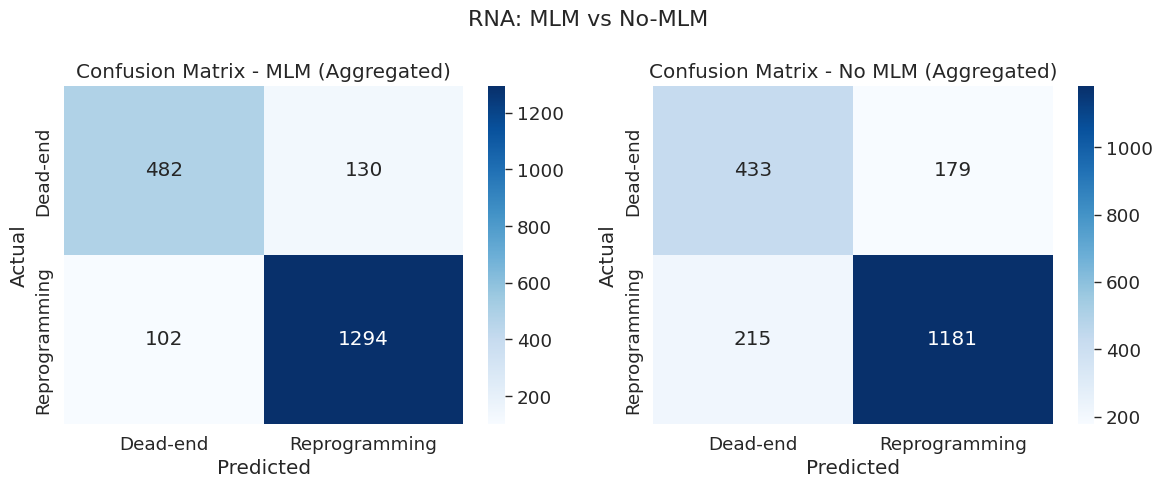

In [14]:
cms_mlm = compute_confusion_matrices("RNA", model_config, fold_results, labelled_dataset, device)
cms_nomlm = compute_confusion_matrices("RNA", model_config, fold_results_nomlm, labelled_dataset, device)
plot_conf_matrix_mlm_vs_nomlm(cms_mlm, cms_nomlm, only_agg=True, m_type="RNA", suptitle="RNA: MLM vs No-MLM")

In [8]:
# compute mean and std of train_auc and best_val_auc keys in fold_results and fold_results_nomlm
train_auc_mlm = np.mean([fr['train_auc'] for fr in fold_results])
train_auc_nomlm = np.mean([fr['train_auc'] for fr in fold_results_nomlm])
train_auc_mlm_std = np.std([fr['train_auc'] for fr in fold_results])
train_auc_nomlm_std = np.std([fr['train_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm = np.mean([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm = np.mean([fr['best_val_auc'] for fr in fold_results_nomlm])
best_val_auc_mlm_std = np.std([fr['best_val_auc'] for fr in fold_results])
best_val_auc_nomlm_std = np.std([fr['best_val_auc'] for fr in fold_results_nomlm])

print(f"Train AUC: MLM: {train_auc_mlm:.4f} ± {train_auc_mlm_std:.4f}, No-MLM: {train_auc_nomlm:.4f} ± {train_auc_nomlm_std:.4f}")
print(f"Best Val AUC: MLM: {best_val_auc_mlm:.4f} ± {best_val_auc_mlm_std:.4f}, No-MLM: {best_val_auc_nomlm:.4f} ± {best_val_auc_nomlm_std:.4f}")

Train AUC: MLM: 0.9261 ± 0.0050, No-MLM: 0.8729 ± 0.0174
Best Val AUC: MLM: 0.9140 ± 0.0148, No-MLM: 0.8588 ± 0.0186


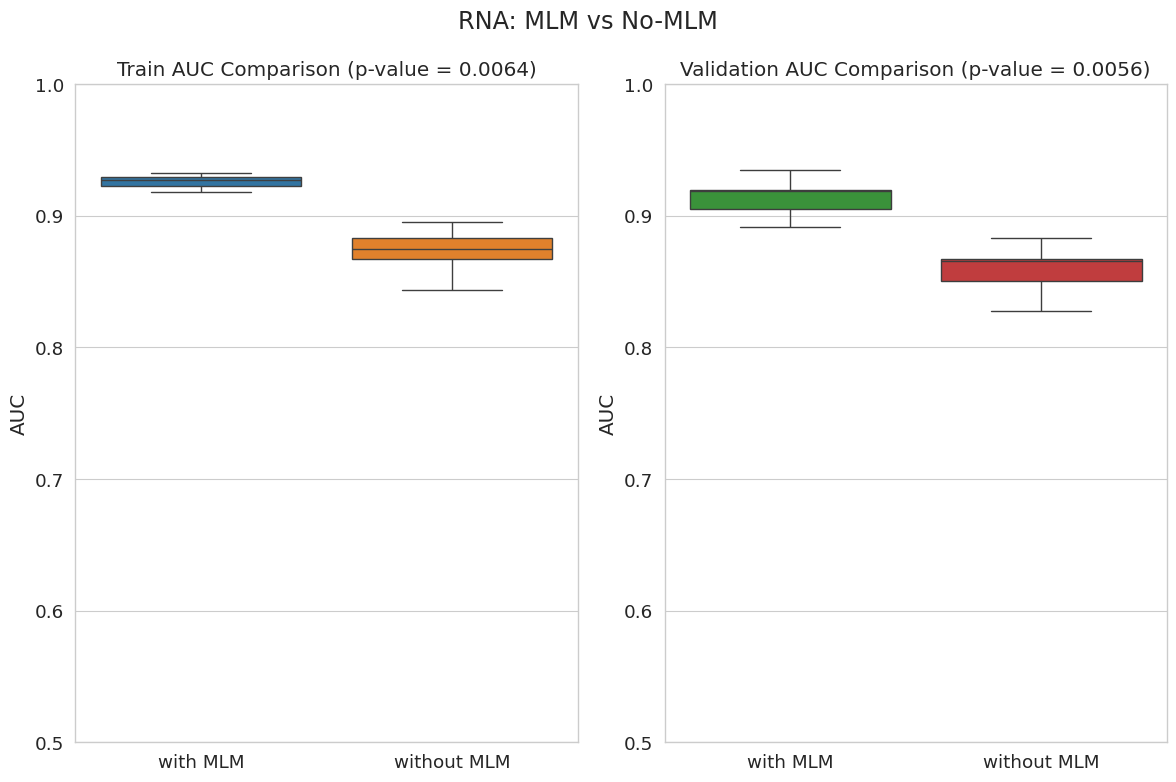

In [9]:
plot_auc_boxplot_comparison(fold_results, fold_results_nomlm, title="RNA: MLM vs No-MLM")

In [10]:
metrics_mlm = compute_metrics_from_confusion_matrix(cms_mlm)
metrics_nomlm = compute_metrics_from_confusion_matrix(cms_nomlm)

avg_mlm = metrics_mlm["average"]
std_mlm = metrics_mlm["std"]
avg_nomlm = metrics_nomlm["average"]
std_nomlm = metrics_nomlm["std"]

print("RNA: MLM")
for k, v in avg_mlm.items():
    print(f"{k}: {v:.4f} ± {std_mlm[k]:.4f}")
print("\nRNA: No-MLM")
for k, v in avg_nomlm.items():
    print(f"{k}: {v:.4f} ± {std_nomlm[k]:.4f}")

RNA: MLM
precision: 0.9060 ± 0.0166
recall: 0.9420 ± 0.0159
f1: 0.9235 ± 0.0097
accuracy: 0.8914 ± 0.0141

RNA: No-MLM
precision: 0.8710 ± 0.0321
recall: 0.8459 ± 0.0594
f1: 0.8562 ± 0.0259
accuracy: 0.8038 ± 0.0290


In [11]:
# print each fold best val auc separate based on mlm and no mlm 5 folds for each)
for i in range(5):
    print(f"Fold {i+1}: MLM: {fold_results[i]['best_val_auc']:.4f}, No-MLM: {fold_results_nomlm[i]['best_val_auc']:.4f}")
print(f"val auc mlm: {np.mean([fr['best_val_auc'] for fr in fold_results]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results]):.4f}")
print(f"val auc no mlm: {np.mean([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f} ± {np.std([fr['best_val_auc'] for fr in fold_results_nomlm]):.4f}")
# compute p-value for mlm and no-mlm values for val auc
from scipy.stats import ttest_rel
print("p-value for val auc: ", ttest_rel([fr['best_val_auc'] for fr in fold_results], [fr['best_val_auc'] for fr in fold_results_nomlm]))

Fold 1: MLM: 0.9194, No-MLM: 0.8832
Fold 2: MLM: 0.9350, No-MLM: 0.8669
Fold 3: MLM: 0.9053, No-MLM: 0.8278
Fold 4: MLM: 0.8912, No-MLM: 0.8657
Fold 5: MLM: 0.9188, No-MLM: 0.8506
val auc mlm: 0.9140 ± 0.0148
val auc no mlm: 0.8588 ± 0.0186
p-value for val auc:  TtestResult(statistic=5.4128261852937, pvalue=0.005643844246290754, df=4)


Evaluating Classifier: 0it [00:00, ?it/s]

['(0.9194 | 0.9194)', '(0.9350 | 0.9350)', '(0.9053 | 0.9053)', '(0.8912 | 0.8912)', '(0.9188 | 0.9188)']


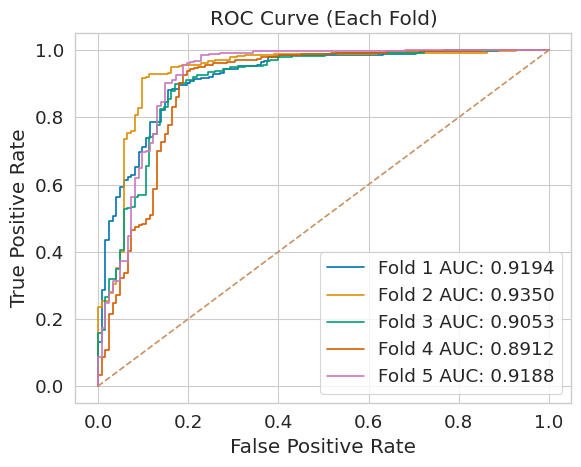

In [12]:
aucs_stored, aucs, val_preds, val_labels = evaluate_cls_cv("RNA", fold_results, model_config, labelled_dataset, device)
print([f"({a:.4f} | {b:.4f})" for a,b in zip(aucs_stored, aucs)])
plot_roc_auc_curve(val_preds, val_labels, m_type="RNA", aggregate=False)

In [ ]:
import json
data_to_store = {
    "modality": "RNA",
    "val_preds": [val_preds[i].tolist() for i in range(5)],
    "val_labels": [val_labels[i].tolist() for i in range(5)]
}
with open('objects/RNA_val_preds.json', 'w') as f:
    json.dump(data_to_store, fp=f)



## Plot Similarity Heatmap

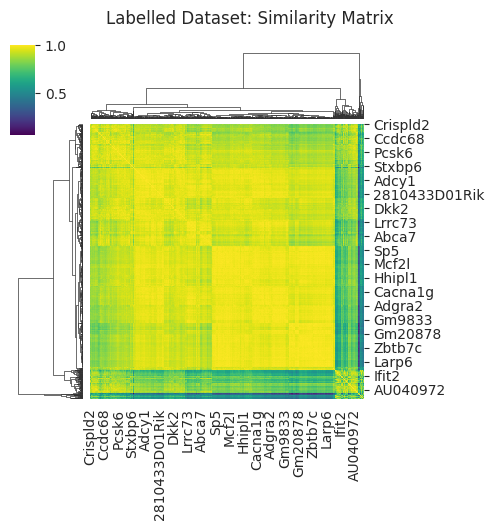

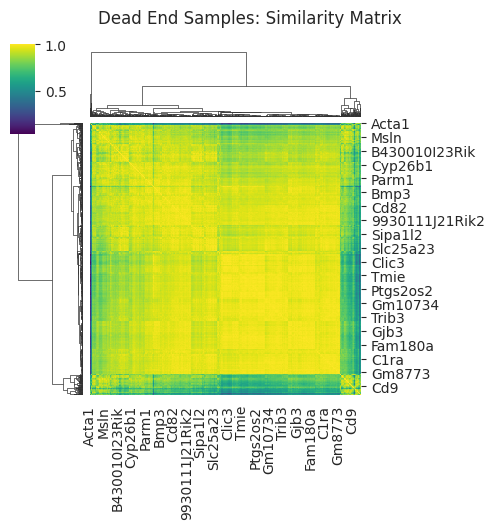

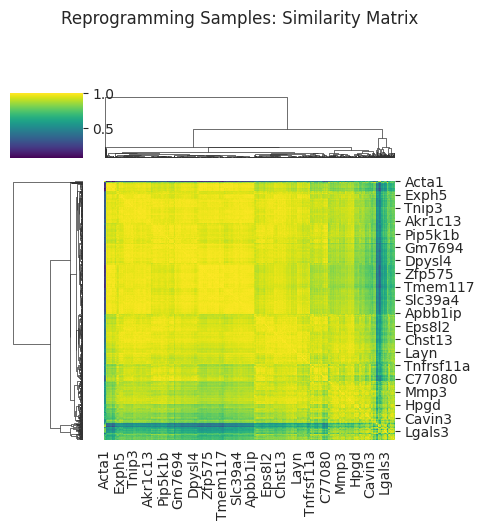

In [15]:
# Compute Similarity Matrix
dead_end_ds, repro_ds = separate_dataset(labelled_dataset)

model = SingleTransformer(id="RNA", **model_config).to(device)
model.load_state_dict(torch.load(config.MLM_RNA_CKP))

sm_labelled = compute_similarity_matrix(model, labelled_dataset, device)
sm_dead_end = compute_similarity_matrix(model, dead_end_ds, device)
sm_repro = compute_similarity_matrix(model, repro_ds, device)

# Create clustermap for Labelled Dataset
df_labelled = pd.DataFrame(sm_labelled, index=gene_names, columns=gene_names)
g1 = sns.clustermap(df_labelled, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g1.fig.suptitle("Labelled Dataset: Similarity Matrix", y=1.05)

# Create clustermap for Dead End Dataset
df_dead_end = pd.DataFrame(sm_dead_end, index=gene_names, columns=gene_names)
g2 = sns.clustermap(df_dead_end, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g2.fig.suptitle("Dead End Samples: Similarity Matrix", y=1.05)

# Create clustermap for Reproducible Dataset
df_repro = pd.DataFrame(sm_repro, index=gene_names, columns=gene_names)
g3 = sns.clustermap(df_repro, row_cluster=True, col_cluster=True, cmap="viridis", figsize=(5, 5))
g3.fig.suptitle("Reprogramming Samples: Similarity Matrix", y=1.05)

plt.tight_layout()
plt.show()

## Analyse Wrong Predictions

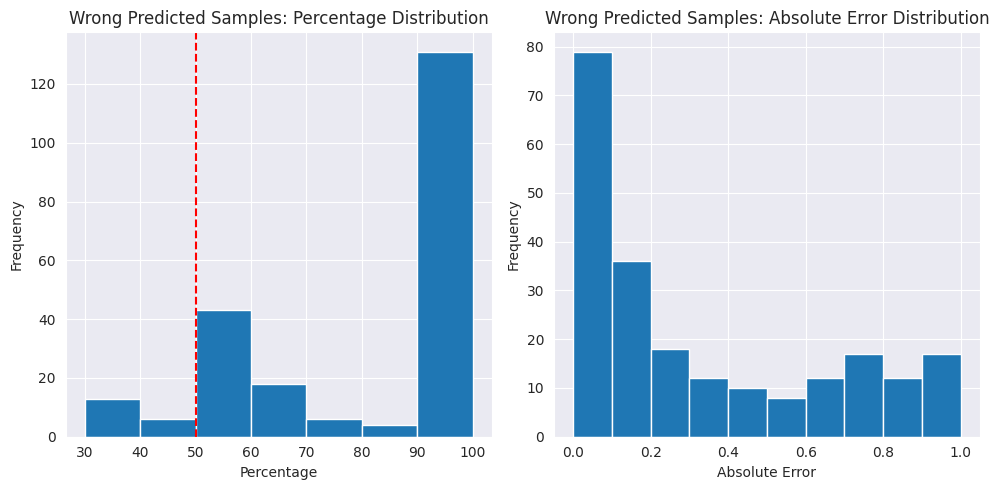

In [16]:
# get valid indices from val_index of fold_results
val_indices = [fr['val_idx'] for fr in fold_results]
# get wrong predicted samples from val_preds and val_labels and val_indices
wrong_preds = []
wrong_indices = []
for p, g, i in zip(np.concatenate(val_preds), np.concatenate(val_labels), np.concatenate(val_indices)):
    if p.round() != g:
        wrong_preds.append(p)
        wrong_indices.append(i)
wrong_pcts = pcts[wrong_indices].numpy().tolist()

# plot wrong_pcts with 10 period bins histogram and plot abs(1- wrong_preds) histogram with 0.1 period bins 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.hist(wrong_pcts, bins=7, range=(30, 100))
ax1.axvline(x=50, color='red', linestyle='--')
ax1.set_title("Wrong Predicted Samples: Percentage Distribution")
ax1.set_xlabel("Percentage")
ax1.set_ylabel("Frequency")

ax2.hist(np.abs(1 - np.array(wrong_preds)), bins=10, range=(0, 1))
ax2.set_title("Wrong Predicted Samples: Absolute Error Distribution")
ax2.set_xlabel("Absolute Error")
ax2.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# # get indices of top 30 wrong predicted samples with highest absolute error
# top_30_wrong_indices = np.argsort(np.abs(1 - np.array(wrong_preds)))[-30:]
# top_30_wrong_pcts = pcts[wrong_indices][top_30_wrong_indices].numpy().tolist()

# # plot top_30_wrong_pcts with 10 period bins histogram and plot abs(1- wrong_preds) histogram with 0.1 period bins
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# ax1.hist(top_30_wrong_pcts, bins=7, range=(30, 100))
# ax1.axvline(x=50, color='red', linestyle='--')
# ax1.set_title("Top 30 Wrong Predicted Samples: Percentage Distribution")
# ax1.set_xlabel("Percentage")
# ax1.set_ylabel("Frequency")

# ax2.hist(np.abs(1 - np.array(wrong_preds))[top_30_wrong_indices], bins=10, range=(0, 1))
# ax2.set_title("Top 30 Wrong Predicted Samples: Absolute Error Distribution")
# ax2.set_xlabel("Absolute Error")
# ax2.set_ylabel("Frequency")

# plt.tight_layout()
# plt.show()

## Plot Latent Space (CLS Token Embeddings)

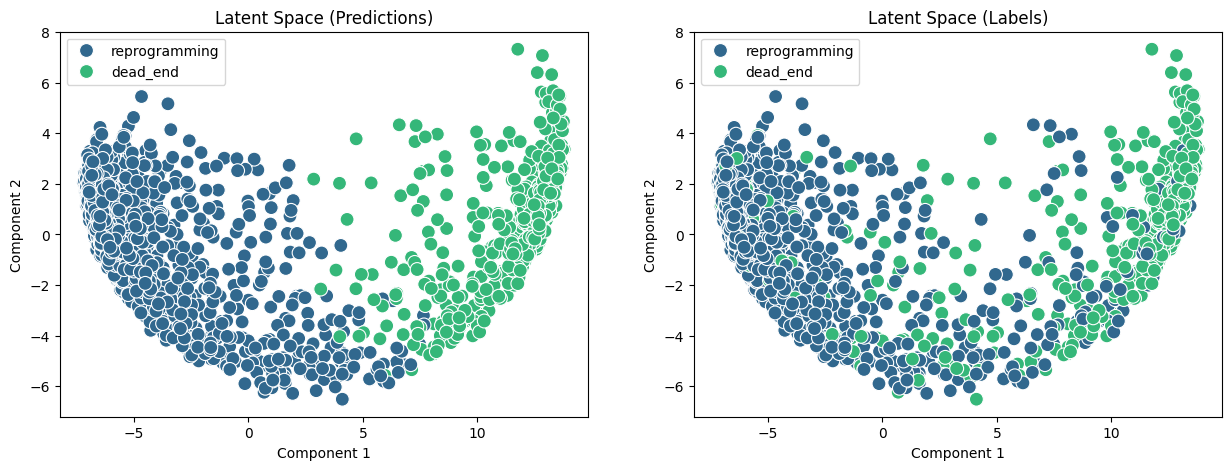

In [18]:
ls, labels, preds = get_latent_space("RNA", fold_results, labelled_dataset, model_config, device)

pca = PCA(n_components=2)
reduced_latent_space = pca.fit_transform(ls)

labels_str = ['reprogramming' if l == 1 else 'dead_end' for l in labels]
preds_str = ['reprogramming' if l == 1 else 'dead_end' for l in preds]
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=reduced_latent_space[:, 0], y=reduced_latent_space[:, 1], hue=preds_str, palette="viridis", s=100)
plt.title('Latent Space (Predictions)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.subplot(1, 2, 2)
sns.scatterplot(x=reduced_latent_space[:, 0], y=reduced_latent_space[:, 1], hue=labels_str, palette="viridis", s=100)
plt.title('Latent Space (Labels)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

## Analyse Shift in Latent Space

In [ ]:
feature_importance = analyze_feature_importance("RNA", model_config, fold_results, labelled_dataset, gene_names, device, perturbation_scale=0.1)

Krt18: 0.5784122943878174
Krt19: 0.4653220474720001
Ctla2a: 0.4375683665275574
Plac8: 0.30348750948905945
Cd9: 0.30168962478637695
S100a4: 0.25215426087379456
Igfbp2: 0.22465212643146515
Sprr2k: 0.22274060547351837
Gsta4: 0.19260245561599731
Apoa1: 0.16666558384895325


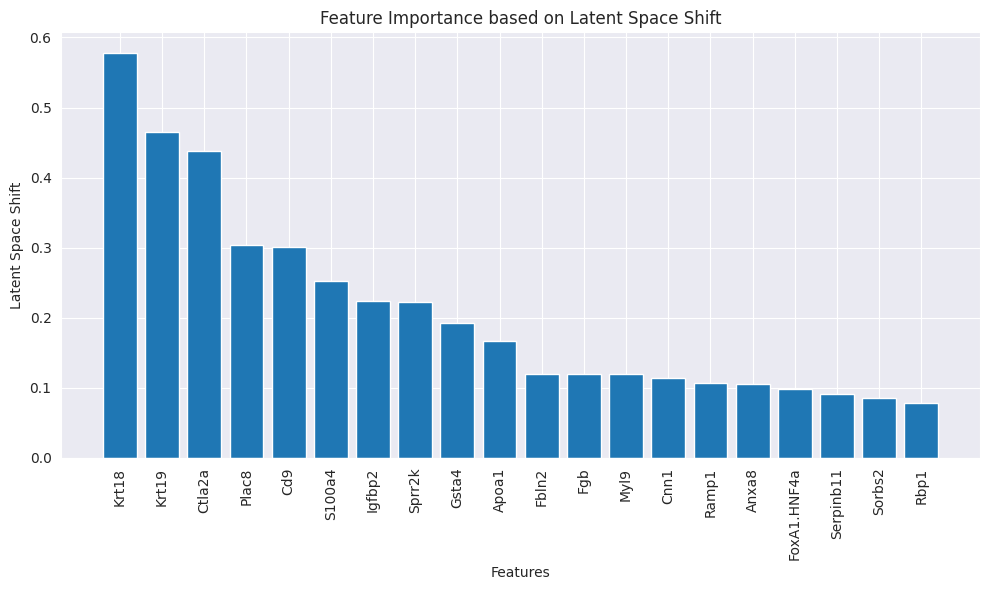

In [31]:

for feature, shift in feature_importance[:10]:
    print(f"{feature}: {shift}")

top_features = feature_importance[:20]
plt.figure(figsize=(10, 6))
plt.bar([f[0] for f in top_features], [f[1] for f in top_features])
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Latent Space Shift')

plt.title('Feature Importance based on Latent Space Shift')
plt.tight_layout()
plt.show()

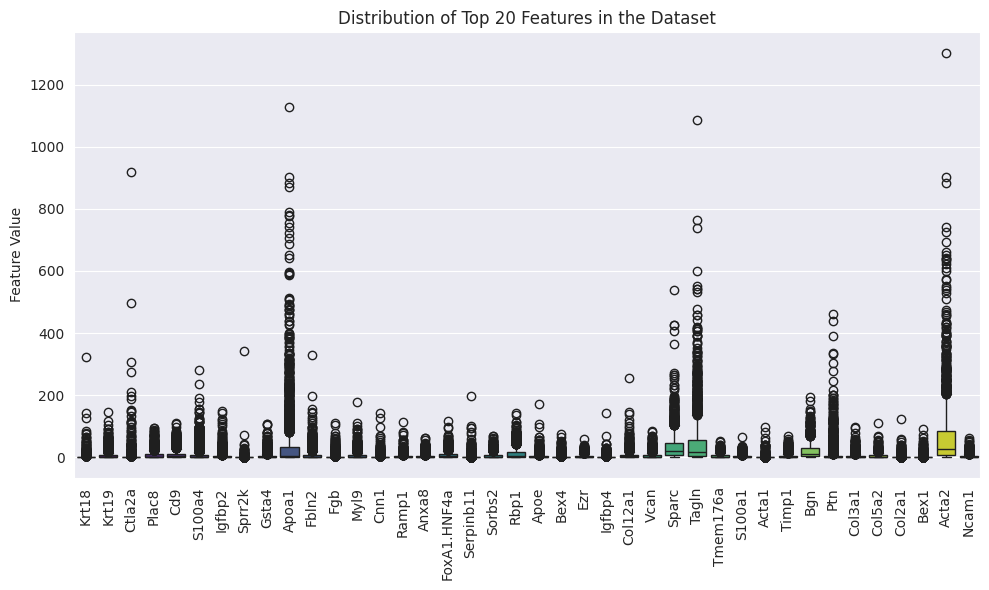

In [30]:
# plot the distribution of the top 20 features in the dataset
top_features_names = [f[0] for f in top_features]
top_features_indices = [gene_names.index(f) for f in top_features_names]
top_features_data = labelled_dataset.tensors[0][:, top_features_indices].numpy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_features_data, palette="viridis")
plt.xticks(range(len(top_features_names)), top_features_names, rotation=90)
plt.ylabel('Feature Value')
plt.title('Distribution of Top 20 Features in the Dataset')
plt.tight_layout()
plt.show()

In [27]:
df_degs[df_degs['gene'].isin(top_features_names)]

,gene,mean_exp_de,mean_exp_re,std_exp_de,std_exp_re,pval,pval_adj,log_fc,group,pval_adj_log
1,S100a4,0.571844,0.600200,0.537123,0.522501,3.588107e-81,2.492299e-77,-1.939278,dead-end,76.603400
2,Krt19,0.242359,0.311126,0.388874,0.365800,4.688901e-74,2.171274e-70,1.974604,reprogramming,69.663285
3,Cd9,0.427027,0.469876,0.424086,0.415566,9.281735e-73,3.223546e-69,1.657683,reprogramming,68.491666
15,Plac8,0.236502,0.240266,0.351972,0.331798,1.792468e-53,1.556311e-50,1.580789,reprogramming,49.807904
21,Fbln2,3.554617,3.724329,0.624769,0.594938,6.540822e-46,4.130232e-43,-1.508055,dead-end,42.384026
22,FoxA1.HNF4a,0.058296,0.051200,0.161778,0.152085,1.193582e-45,7.209237e-43,1.349621,reprogramming,42.142111
23,Anxa8,0.315724,0.315176,0.375375,0.392630,1.601183e-45,9.268180e-43,1.749500,reprogramming,42.033006
29,Rbp1,0.060121,0.083107,0.180437,0.210967,1.440329e-42,6.669683e-40,1.180173,reprogramming,39.175895
47,Cnn1,0.381080,0.398150,0.421593,0.392702,2.503271e-35,7.170719e-33,-2.365997,dead-end,32.144437
48,Sorbs2,0.269325,0.316461,0.361752,0.371462,2.529263e-35,7.170719e-33,1.160820,reprogramming,32.144437
